# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

Question 1:
Markups are fairly compressed across brands ($38–$46), meaning price differences mostly reflect cost differences. Cuisinart has the highest average unit cost ($183) and Dash the lowest ($16). Ninja and Instant Pot lead on share-weighted average profit.

Question 2:
There are no negative unit costs in this data. If there were, it would signal a misspecified model — likely a positive (wrong-sign) price coefficient, which would cause the denominator in the markup formula to flip sign and push inferred costs below zero.

Question 3:
 The highest average unit costs belong to Cuisinart (~$183), Oster ($151), and Ninja ($99). Price and unit cost are strongly positively correlated — more expensive products really do cost more to make. However, the relationship between rating and unit cost is weak. Higher-cost brands don't consistently receive better reviews, suggesting consumers don't always perceive quality commensurate with price.

Question 4:


Question 5:
Ninja leads with an average profit index of ~8.91, followed closely by Instant Pot (~8.49) and GoWise USA (~6.50). Oster (~0.96) brings up the rear despite having a high price — its very low market share drags down its share-weighted profit. This tells you that in this market, volume (share) matters as much as margin.


In [ ]:
# Q3 - Setup: re-run Q2 model, then compute demand slope, unit cost, markup, average profit

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('air_fryers_clean_brand_year.csv')

# Rebuild the Q2 model
y = np.log(df['brand_share'])
df_dummies = pd.get_dummies(df, columns=['brand', 'year'], drop_first=True)

product_features = ['compact_share', 'dual_basket_share', 'oven_style_share', 'rotisserie_share', 'window_share']
features_to_include = ['avg_price', 'avg_rating'] + product_features
dummy_cols = [col for col in df_dummies.columns if col.startswith('brand_') or col.startswith('year_')]

X = df_dummies[features_to_include + dummy_cols].astype(float)
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

beta_price = model.params['avg_price']
print(f"beta_price = {beta_price:.6f}")

# Q3 computations
df['demand_slope']   = beta_price * df['brand_share'] * (1 - df['brand_share'])
df['unit_cost']      = df['avg_price'] + df['brand_share'] / df['demand_slope']
df['markup']         = df['avg_price'] - df['unit_cost']
df['average_profit'] = df['brand_share'] * df['markup']

print("\nNew columns added successfully:")
print(df[['brand', 'year', 'avg_price', 'unit_cost', 'markup', 'average_profit']].round(3))

beta_price = -0.026674

New columns added successfully:
          brand  year  avg_price  unit_cost  markup  average_profit
0       chefman  2019     72.964     32.390  40.573           3.084
1        cosori  2019    159.990    122.473  37.517           0.027
2     cuisinart  2019    229.465    187.475  41.990           4.501
3          dash  2019     55.176      8.331  46.845           9.356
4    gowise usa  2019     83.576     30.611  52.965          15.476
5   instant_pot  2019     78.020     39.929  38.091           0.601
6         ninja  2019    112.158     65.725  46.433           8.944
7        nuwave  2019    151.100    112.367  38.733           1.243
8         oster  2019    191.944    153.152  38.791           1.302
9       ultrean  2019     80.625     41.159  39.466           1.976
10      chefman  2020     97.426     57.623  39.803           2.314
11       cosori  2020    115.649     77.836  37.814           0.325
12    cuisinart  2020    227.915    186.161  41.754         

In [ ]:
# Q3 - Setup: compute demand slope, unit cost, markup, average profit

beta_price = model.params['avg_price']

df['demand_slope']   = beta_price * df['brand_share'] * (1 - df['brand_share'])
df['unit_cost']      = df['avg_price'] + df['brand_share'] / df['demand_slope']
df['markup']         = df['avg_price'] - df['unit_cost']
df['average_profit'] = df['brand_share'] * df['markup']

print("New columns added: demand_slope, unit_cost, markup, average_profit")
print(df[['brand', 'year', 'avg_price', 'demand_slope', 'unit_cost', 'markup', 'average_profit']].round(3))

New columns added: demand_slope, unit_cost, markup, average_profit
          brand  year  avg_price  demand_slope  unit_cost  markup  \
0       chefman  2019     72.964        -0.002     32.390  40.573   
1        cosori  2019    159.990        -0.000    122.473  37.517   
2     cuisinart  2019    229.465        -0.003    187.475  41.990   
3          dash  2019     55.176        -0.004      8.331  46.845   
4    gowise usa  2019     83.576        -0.006     30.611  52.965   
5   instant_pot  2019     78.020        -0.000     39.929  38.091   
6         ninja  2019    112.158        -0.004     65.725  46.433   
7        nuwave  2019    151.100        -0.001    112.367  38.733   
8         oster  2019    191.944        -0.001    153.152  38.791   
9       ultrean  2019     80.625        -0.001     41.159  39.466   
10      chefman  2020     97.426        -0.001     57.623  39.803   
11       cosori  2020    115.649        -0.000     77.836  37.814   
12    cuisinart  2020    227.915    

In [ ]:
# Q3-1: Average unit costs and markups per brand (averaged over years)

brand_summary = df.groupby('brand')[['avg_price', 'unit_cost', 'markup', 'average_profit']].mean().round(2)
brand_summary = brand_summary.sort_values('unit_cost', ascending=False)
print("Average Unit Costs and Markups by Brand:")
print(brand_summary)

Average Unit Costs and Markups by Brand:
             avg_price  unit_cost  markup  average_profit
brand                                                    
cuisinart       223.95     182.92   41.02            3.53
oster           189.03     150.58   38.45            0.96
ninja           145.34      98.95   46.39            8.91
nuwave          137.02      97.53   39.50            2.01
cosori          114.27      74.75   39.52            2.03
instant_pot     104.46      58.48   45.98            8.49
chefman          90.94      49.47   41.47            3.98
gowise usa       87.45      43.46   43.99            6.50
ultrean          78.11      36.70   41.42            3.93
dash             57.48      15.76   41.72            4.23


In [ ]:
# Q3-2: Are any inferred unit costs negative?

neg_costs = df[df['unit_cost'] < 0]
print(f"Number of brand-years with negative unit cost: {len(neg_costs)}")

if len(neg_costs) > 0:
    print(neg_costs[['brand', 'year', 'avg_price', 'brand_share', 'unit_cost']])
else:
    print("No negative unit costs — the model is internally consistent.")

Number of brand-years with negative unit cost: 0
No negative unit costs — the model is internally consistent.


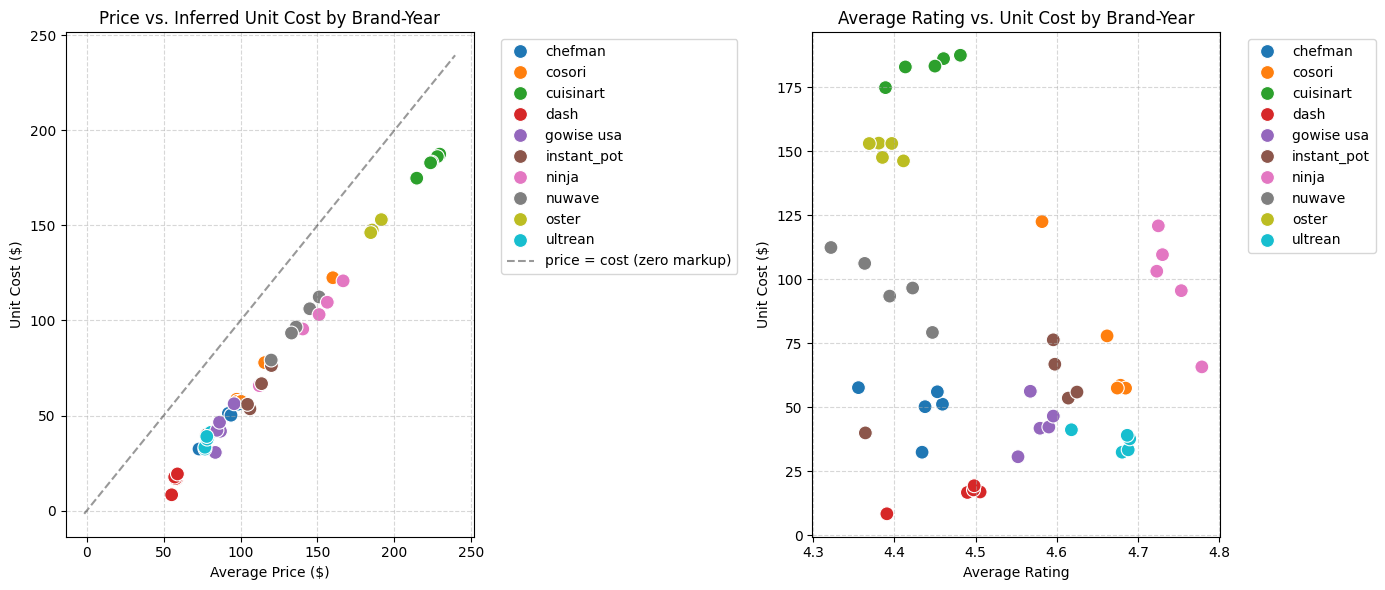

In [ ]:
# Q3-3: Scatter plots — price vs. unit cost, and avg_rating vs. unit cost

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Price vs Unit Cost
sns.scatterplot(data=df, x='avg_price', y='unit_cost', hue='brand', s=100, ax=axes[0])
axes[0].set_title('Price vs. Inferred Unit Cost by Brand-Year')
axes[0].set_xlabel('Average Price ($)')
axes[0].set_ylabel('Unit Cost ($)')
lims = [min(df['avg_price'].min(), df['unit_cost'].min()) - 10,
        max(df['avg_price'].max(), df['unit_cost'].max()) + 10]
axes[0].plot(lims, lims, 'k--', alpha=0.4, label='price = cost (zero markup)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Rating vs Unit Cost
sns.scatterplot(data=df, x='avg_rating', y='unit_cost', hue='brand', s=100, ax=axes[1])
axes[1].set_title('Average Rating vs. Unit Cost by Brand-Year')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Unit Cost ($)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

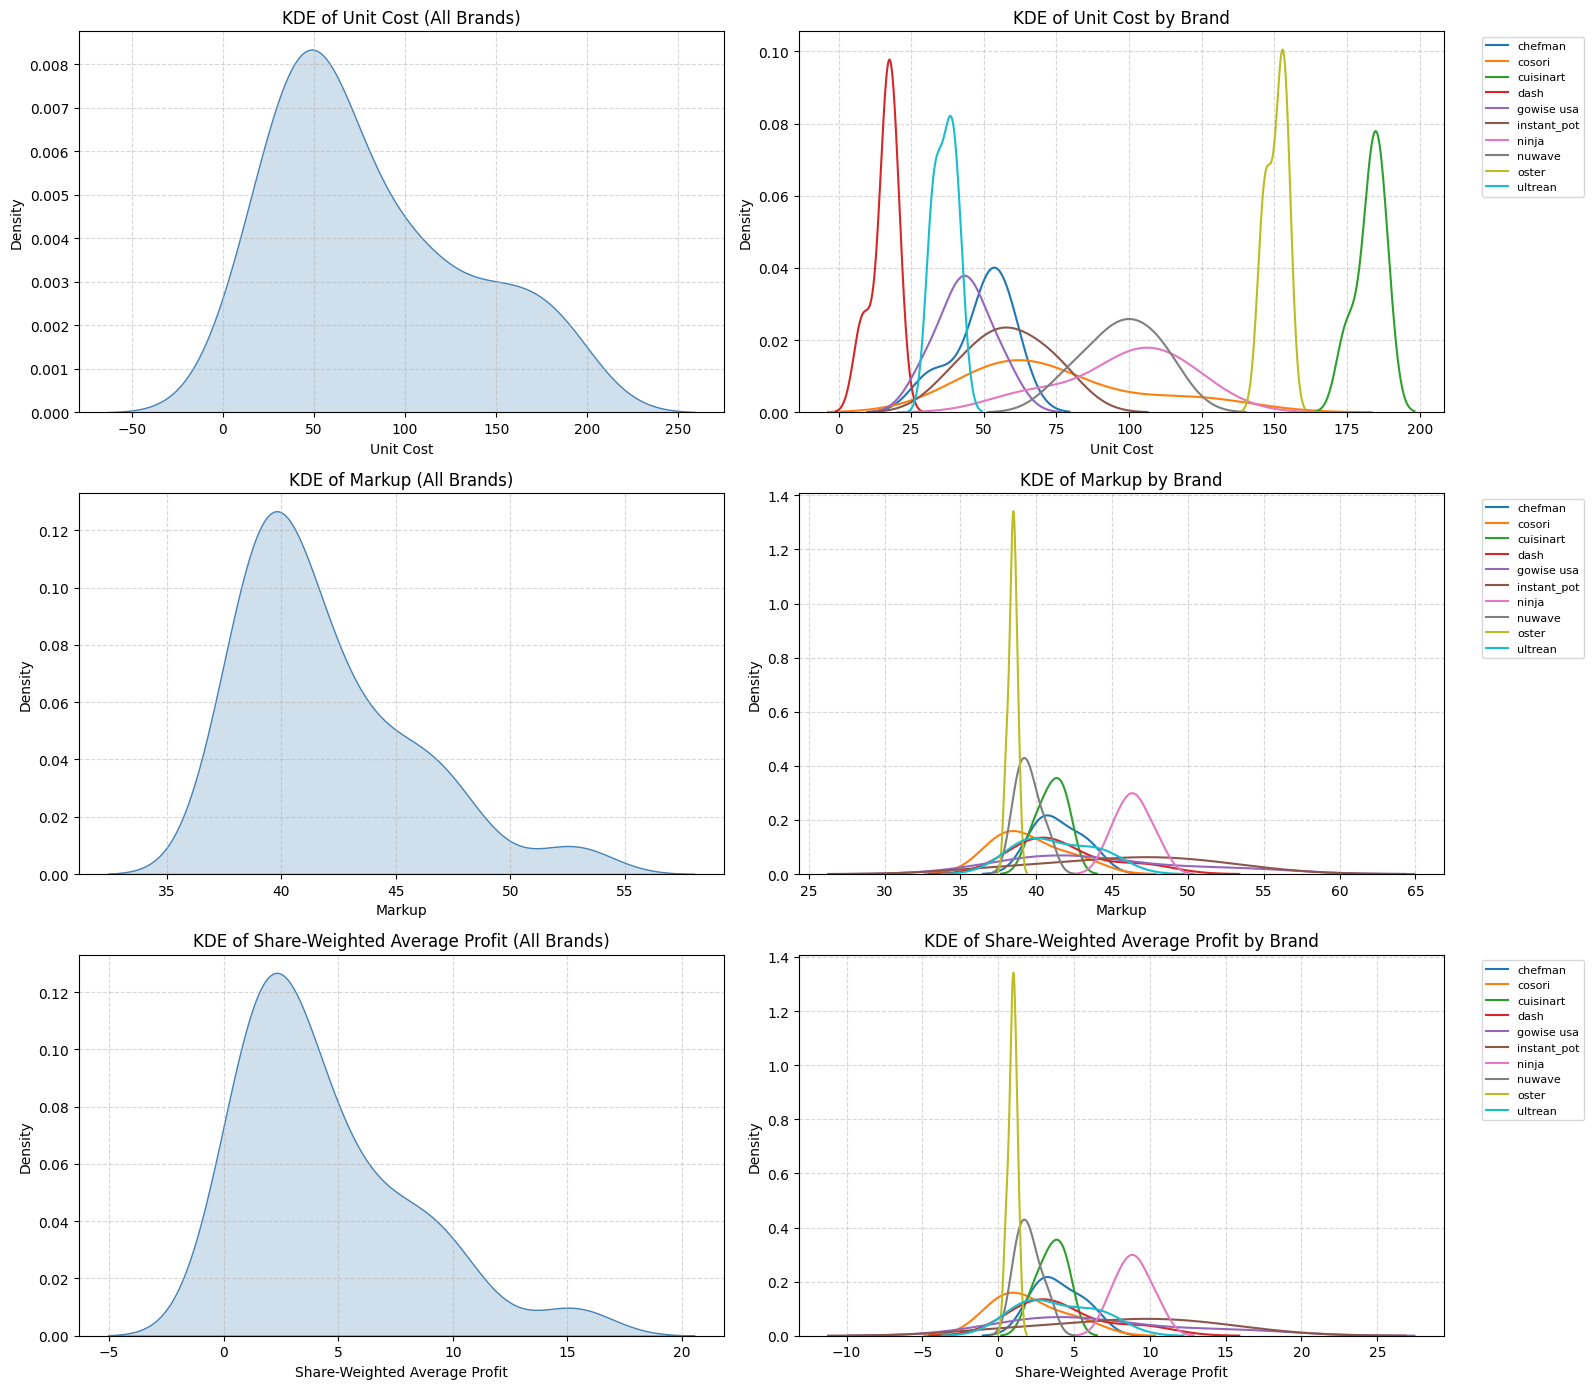

In [ ]:
# Q3-4: KDE plots of unit costs, markups, and average profit — overall and by brand

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
variables = ['unit_cost', 'markup', 'average_profit']
titles    = ['Unit Cost', 'Markup', 'Share-Weighted Average Profit']

for i, (var, title) in enumerate(zip(variables, titles)):
    # Left: overall KDE
    sns.kdeplot(df[var], fill=True, ax=axes[i][0], color='steelblue')
    axes[i][0].set_title(f'KDE of {title} (All Brands)')
    axes[i][0].set_xlabel(title)
    axes[i][0].grid(True, linestyle='--', alpha=0.5)

    # Right: by brand
    for brand, grp in df.groupby('brand'):
        sns.kdeplot(grp[var], fill=False, label=brand, ax=axes[i][1])
    axes[i][1].set_title(f'KDE of {title} by Brand')
    axes[i][1].set_xlabel(title)
    axes[i][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[i][1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Share-Weighted Average Profit by Brand (higher = more profitable):
brand
ninja          8.9050
instant_pot    8.4873
gowise usa     6.5040
dash           4.2285
chefman        3.9836
ultrean        3.9269
cuisinart      3.5346
cosori         2.0287
nuwave         2.0093
oster          0.9579
Name: average_profit, dtype: float64


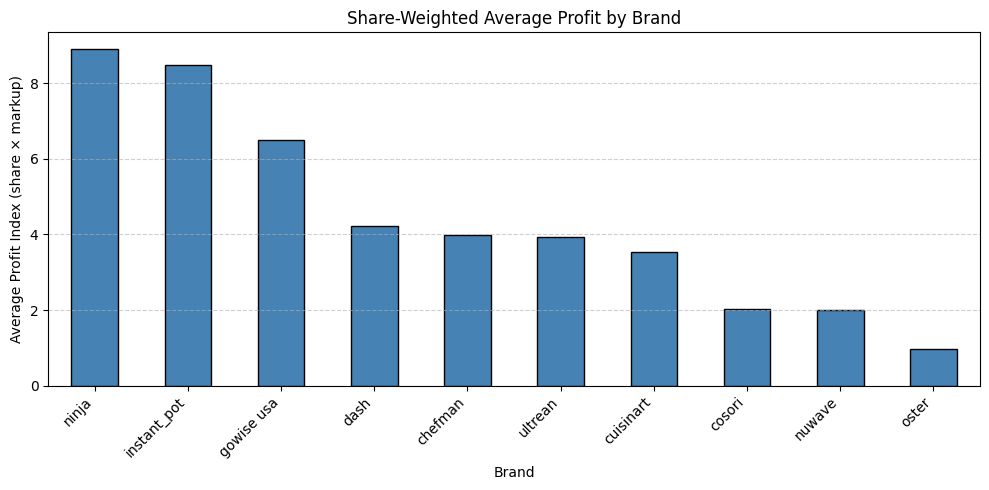

In [ ]:
# Q3-5: Which brands have the highest share-weighted average profit?

profit_by_brand = df.groupby('brand')['average_profit'].mean().sort_values(ascending=False).round(4)
print("Share-Weighted Average Profit by Brand (higher = more profitable):")
print(profit_by_brand)

# Bar chart for easy visualization
plt.figure(figsize=(10, 5))
profit_by_brand.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Share-Weighted Average Profit by Brand')
plt.ylabel('Average Profit Index (share × markup)')
plt.xlabel('Brand')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()